# Data Analysis
## Load Data
### Imports

In [2]:
import os 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import ipywidgets as widgets
from IPython.display import display, clear_output

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression

### Load Data

In [3]:
base_dir = os.getcwd()
data_dir = os.path.join(base_dir, 'data')

ausgrid_complete_filepath = os.path.join(data_dir, 'ausgrid_complete.csv')
ausgrid_ppv_filepath = os.path.join(data_dir, 'ausgrid_ppv.csv')

# ausgrid_complete = pd.read_csv(ausgrid_complete_filepath)
ausgrid_ppv = pd.read_csv(ausgrid_ppv_filepath)

# Inspect data
print(f"Name: Ausgrid PPV Data")
print(f"Shape: {ausgrid_ppv.shape}")
print(f"Columns:", ausgrid_ppv.columns.tolist())
print(f"Missing values: {ausgrid_ppv.isna().sum().sum()}")
ausgrid_ppv.head()

Name: Ausgrid PPV Data
Shape: (15778212, 13)
Columns: ['Customer', 'Generator Capacity', 'Postcode', 'datetime', 'PPV', 'temperature_2m', 'wind_speed_10m', 'shortwave_radiation', 'cloud_cover', 'direct_normal_irradiance', 'diffuse_radiation', 'sunshine_duration', 'sun_position']
Missing values: 0


,Customer,Generator Capacity,Postcode,datetime,PPV,temperature_2m,wind_speed_10m,shortwave_radiation,cloud_cover,direct_normal_irradiance,diffuse_radiation,sunshine_duration,sun_position
0,1,3.78,2076,2010-07-01 00:00:00,0.0,3.60,8.30,0.0,1.0,0.0,0.0,0.0,122.979516
1,1,3.78,2076,2010-07-01 00:30:00,0.0,3.45,8.35,0.0,5.0,0.0,0.0,0.0,122.534587
2,1,3.78,2076,2010-07-01 01:00:00,0.0,3.30,8.40,0.0,9.0,0.0,0.0,0.0,121.220214
3,1,3.78,2076,2010-07-01 01:30:00,0.0,2.75,8.45,0.0,15.5,0.0,0.0,0.0,119.093277
4,1,3.78,2076,2010-07-01 02:00:00,0.0,2.20,8.50,0.0,22.0,0.0,0.0,0.0,116.236036


## Characterize PPV time series
### Prepare Data

In [13]:
# Prepare data for interactive exploration
df = ausgrid_ppv.copy()
df["datetime"] = pd.to_datetime(df["datetime"])

df["date"] = df["datetime"].dt.date
df["time"] = (
    df["datetime"].dt.hour
    + df["datetime"].dt.minute / 60)

# Get available customers
customers = sorted(df["Customer"].dropna().unique())

### Create interactive controls

In [14]:
# Create customer and date selection widgets
customer_dropdown = widgets.Dropdown(
    options=customers,
    description="Customer:",
    layout=widgets.Layout(width="400px"))

date_dropdown = widgets.Dropdown(
    description="Date:",
    layout=widgets.Layout(width="400px"))

# Output area for the plot
output = widgets.Output()

### Define functions for updating the dashboard

In [20]:
# Update available dates when the customer changes
def update_dates(change):
    customer = change["new"]

    customer_df = df[df["Customer"] == customer]
    dates = sorted(customer_df["date"].unique())

    date_dropdown.options = dates

    if dates:
        date_dropdown.value = dates[0]


# Draw all currently selected profiles
def update_plot():
    with output:
        clear_output(wait=True)

        plt.figure(figsize=(10, 5))

        for customer, date in profiles:

            day_df = df[
                (df["Customer"] == customer) &
                (df["date"] == date)
            ].sort_values("datetime")

            plt.plot(
                day_df["time"],
                day_df["PPV"],
                label=f"Customer {customer} — {date}"
            )

        plt.xlabel("Time of day")
        plt.ylabel("PPV")
        plt.title("PV Power Profiles")

        if profiles:
            plt.legend()

        plt.grid(True)
        plt.tight_layout()
        plt.show()


def add_profile(change=None):
    customer = customer_dropdown.value
    date = date_dropdown.value

    if customer is None or date is None:
        return

    profile = (customer, date)

    # Prevent duplicate profiles
    if profile not in profiles:
        # Show loading state
        add_button.description = "Adding..."
        add_button.disabled = True

        profiles.append(profile)

        update_plot()

        # Restore button
        add_button.description = "Add profile"
        add_button.disabled = False


# Remove all profiles from the plot
def clear_profiles(change=None):
    profiles.clear()
    update_plot()

### Connect and initialize the dashboard

In [21]:
# Store profiles that have been added to the plot
profiles = []

In [22]:
# Create buttons
add_button = widgets.Button(
    description="Add profile",
    button_style="primary",
    layout=widgets.Layout(width="150px")
)

clear_button = widgets.Button(
    description="Clear profiles",
    layout=widgets.Layout(width="150px")
)


# Connect widgets to functions
customer_dropdown.observe(update_dates, names="value")
add_button.on_click(add_profile)
clear_button.on_click(clear_profiles)


# Initialize the date dropdown
update_dates({"new": customer_dropdown.value})


# Display dashboard
display(
    widgets.VBox([
        customer_dropdown,
        date_dropdown,
        widgets.HBox([
            add_button,
            clear_button
        ])
    ]),
    output
)


# Initial empty plot
update_plot()

Output(outputs=({'output_type': 'display_data', 'data': {'text/plain': '<Figure size 1000x500 with 1 Axes>', '…

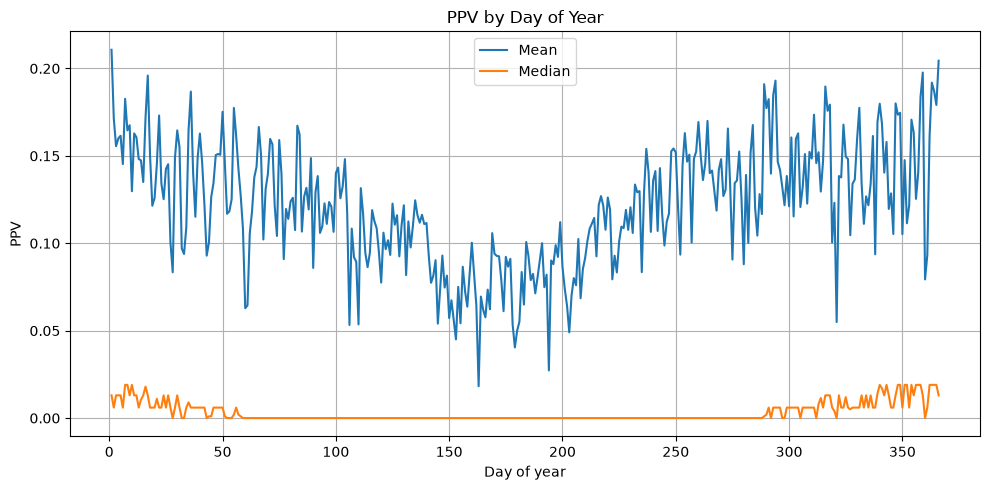

In [23]:
# PPV by day of year for each customer
plt.figure(figsize=(10, 5))

for customer in selected_customers:
    customer_df = df[df["customer_id"] == customer].copy()
    customer_df["day_of_year"] = customer_df["datetime"].dt.dayofyear
    
    daily_curve = customer_df.groupby("day_of_year")["PPV"].mean()
    plt.plot(daily_curve.index, daily_curve.values, label=f"Customer {customer}")

plt.xlabel("Day of year")
plt.ylabel("PPV")
plt.title("PPV by Day of Year — Five Random Customers")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Baseline Models
### Simple Mean

In [26]:
# Mean baseline
y_true = ausgrid_ppv["PPV"].dropna()
y_pred = np.full(len(y_true), y_true.mean())

print("MAE:", mean_absolute_error(y_true, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))
print("R²:", r2_score(y_true, y_pred))

MAE: 0.15885393750216514
RMSE: 0.24447507076458846
R²: 0.0


With an an MAE of 0.159 and an RMSE of 0.244, the mean is a weak predictor. As expected, $R^2=0$ because predicting the mean explains none of the variation in PPV. 

### Historical PV

We predict each PPV observation using the PPV recorded at the same date and time exactly one year earlier. 

In [35]:
# Historical baseline: PPV from exactly one year earlier for one customer
customer_id = ausgrid_ppv["Customer"].iloc[0]

df = ausgrid_ppv[ausgrid_ppv["Customer"] == customer_id][
    ["datetime", "PPV"]
].dropna().copy()

df["datetime"] = pd.to_datetime(df["datetime"])

ppv_lookup = df.drop_duplicates("datetime").set_index("datetime")["PPV"]

prev_dates = df["datetime"] - pd.DateOffset(years=1)
df["PPV_prev_year"] = ppv_lookup.reindex(prev_dates).to_numpy()

df = df.dropna(subset=["PPV_prev_year"])

print("Customer:", customer_id)
print("MAE:", mean_absolute_error(df["PPV"], df["PPV_prev_year"]))
print("RMSE:", np.sqrt(mean_squared_error(df["PPV"], df["PPV_prev_year"])))
print("R²:", r2_score(df["PPV"], df["PPV_prev_year"]))

Customer: 1
MAE: 0.14911613988086758
RMSE: 0.3210761293066749
R²: 0.4859198583646622


For this individual customer, the previous-year PPV is a much more useful baseline than the simple mean. MAE = 0.149 and RMSE = 0.322 indicate that reasonably large prediction errors remain. $R^2=0.489$ means the previous year's PPV explains about 49% of the variation in the current year's PPV. 

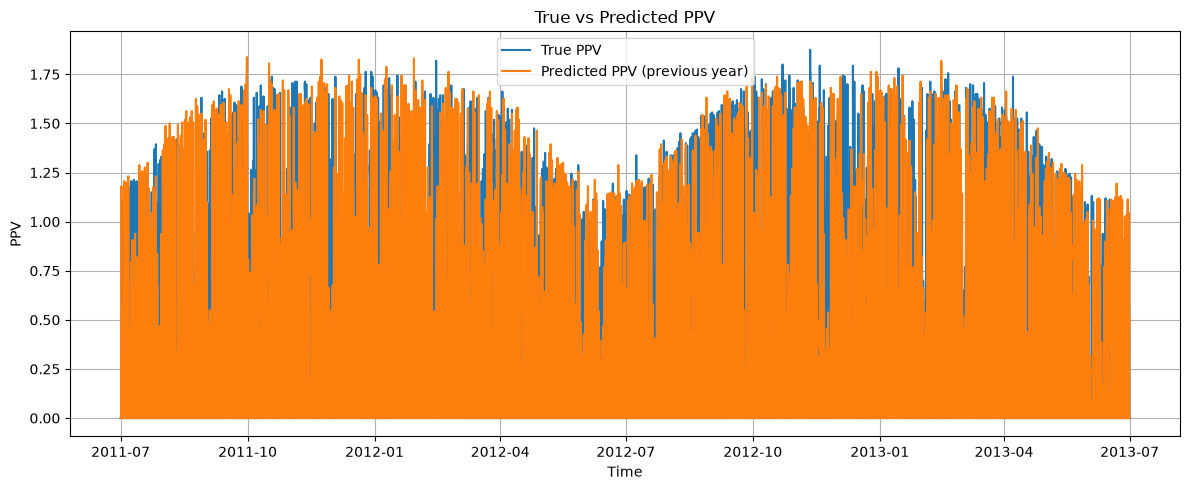

In [36]:
plt.figure(figsize=(12, 5))

plt.plot(df["datetime"], df["PPV"], label="True PPV")
plt.plot(df["datetime"], df["PPV_prev_year"], label="Predicted PPV (previous year)")

plt.xlabel("Time")
plt.ylabel("PPV")
plt.title("True vs Predicted PPV")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

The plot shows that the previous year's data captures the overall seasonal pattern and approximate magnitude, bus misses much of the day-to-day variability, particularly weather-driven fluctuations.

## Univariate predictors
### Functions

In [53]:
def univariate_predictor(var_name):
    # Single-variable predictor
    df = ausgrid_ppv[ausgrid_ppv["Customer"] == customer_id][
        ["datetime", "PPV", var_name]
    ].dropna().copy()
    
    X = df[[var_name]]
    y = df["PPV"]
    
    model = LinearRegression()
    model.fit(X, y)
    
    y_pred = model.predict(X)
    
    mae = mean_absolute_error(y, y_pred)
    rmse = np.sqrt(mean_squared_error(y, y_pred))
    r2 = r2_score(y, y_pred)
    return mae, rmse, r2

In [54]:
def predictors_table(var_name_list):
    results = []
    for var_name in var_name_list:
        mae, rmse, r2 = univariate_predictor(var_name)
        results.append({
            "Variable": var_name,
            "MAE": mae,
            "RMSE": rmse,
            "R²": r2})
    return pd.DataFrame(results)

### Results

In [55]:
variables = [
    "temperature_2m",
    "wind_speed_10m",
    "shortwave_radiation",
    "cloud_cover",
    "direct_normal_irradiance",
    "diffuse_radiation",
    "sunshine_duration",
    "sun_position"
]

results = predictors_table(variables)
results

,Variable,MAE,RMSE,R²
0,temperature_2m,0.288650,0.378234,0.283793
1,wind_speed_10m,0.339983,0.436573,0.045819
2,shortwave_radiation,0.109589,0.192306,0.814859
3,cloud_cover,0.353936,0.444916,0.009001
4,direct_normal_irradiance,0.152600,0.262576,0.654835
5,diffuse_radiation,0.214889,0.334531,0.439740
6,sunshine_duration,0.191763,0.318296,0.492801
7,sun_position,0.257609,0.348042,0.393571


`Shortwave radiation` is the strongest predictor, followed by `direct normal irradiance` and `diffuse radiation`. Temperature and sun position provide some predictive information. Wind speed and cloud cover have very little standalone predictive power.

## Plane-of-array POA irradiance
Total solar irradiance incident on the PV panel surface.

$\text{POA} = \text{DNI} \cos (\theta_z) + \text{DHI}$

In [57]:
# Calculate plane-of-array (POA) irradiance
ausgrid_ppv["poa"] = (
    ausgrid_ppv["direct_normal_irradiance"] *
    np.cos(np.radians(ausgrid_ppv["sun_position"])) +
    ausgrid_ppv["diffuse_radiation"])

In [65]:
# POA adjusted for cloud cover
ausgrid_ppv["poa_cloud"] = (
    ausgrid_ppv["poa"] *
    (1 - ausgrid_ppv["cloud_cover"]))

## Temperature correction factor for PV efficiency
$\text{TCF} = 1 - \beta \times (T_\text{cell} - T_\text{ref})$
- $\beta$ = PV module temperature coefficient of power  $\approx 0.004 / \degree C$.

$T_\text{cell} = T_\text{2m} + \frac{\text{POA}}{U_0 + U_1 v}$

- $T_\text{cell}$ = PV cell temperature.
- $T_\text{2m}$ = Outdoor temperature.
- POA = Plane-of-array irradiance.
- $U_0$ = 25 W m$^{-2}$ K$^{-1}$.
- $U_1$ = 6.84 W m$^{-2}$ K$^{-1}$ / (m/s).

In [63]:
# Temperature correction factor
beta = 0.004  # 1/°C
T_ref = 25    # °C
U0 = 25       # W/m²/K
U1 = 6.84     # W/m²/K per (m/s)

# Cell temperature
ausgrid_ppv["Tcell"] = (
    ausgrid_ppv["temperature_2m"] +
    ausgrid_ppv["poa"] /
    (U0 + U1 * ausgrid_ppv["wind_speed_10m"])
)

# Temperature correction factor
ausgrid_ppv["TCF"] = 1 - beta * (
    ausgrid_ppv["Tcell"] - T_ref)

In [67]:
variables = [
    "temperature_2m",
    "wind_speed_10m",
    "shortwave_radiation",
    "cloud_cover",
    "direct_normal_irradiance",
    "diffuse_radiation",
    "sunshine_duration",
    "sun_position",
    "poa",
    "TCF"]

results = predictors_table(variables)
results

,Variable,MAE,RMSE,R²
0,temperature_2m,0.288650,0.378234,0.283793
1,wind_speed_10m,0.339983,0.436573,0.045819
2,shortwave_radiation,0.109589,0.192306,0.814859
3,cloud_cover,0.353936,0.444916,0.009001
4,direct_normal_irradiance,0.152600,0.262576,0.654835
5,diffuse_radiation,0.214889,0.334531,0.439740
6,sunshine_duration,0.191763,0.318296,0.492801
7,sun_position,0.257609,0.348042,0.393571
8,poa,0.143535,0.248402,0.691094
9,TCF,0.239228,0.310432,0.517552


## Multivariate Model
### Function

In [74]:
def multivariate_predictor(var_name_list):
    # Multivariate predictor
    df = ausgrid_ppv[ausgrid_ppv["Customer"] == customer_id][
        ["datetime", "PPV"] + var_name_list
    ].dropna().copy()

    X = df[var_name_list]
    y = df["PPV"]

    model = LinearRegression()
    model.fit(X, y)

    y_pred = model.predict(X)

    mae = mean_absolute_error(y, y_pred)
    rmse = np.sqrt(mean_squared_error(y, y_pred))
    r2 = r2_score(y, y_pred)

    return mae, rmse, r2

In [77]:
variables = ["shortwave_radiation", "sunshine_duration"]
mae, rmse, r2 = multivariate_predictor(variables)
print(f"MAE: {mae}")
print(f"RMSE: {rmse}")
print(f"R2: {r2}")

MAE: 0.10482026847530865
RMSE: 0.1917745930747286
R2: 0.815880891745079
